<h2 style="text-align: center;"> SISTEMA INTELIGENTE PARA EL APOYO AL DIAGNÓSTICO DE NEUMONÍA MEDIANTE INGENIERIA ETL Y MACHINE LEARNING </h2>

![Logo ITQ](img/ITQ.jpg)

**Nombre:** *Sebastian Sampedro* <br>
**Fecha:** *1/7/2026* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

In [1]:
# BLOQUE 1: IMPORTACIÓN DE LIBRERÍAS

import os             # Para navegar por la estructura de carpetas (rutas de archivos).
import glob           # Para buscar múltiples archivos que coincidan con un patrón (ej. buscar todos los .jpeg).
import numpy as np    # Para cálculos matemáticos rápidos y manejo de matrices (arrays).
import pandas as pd   # Para crear y manipular DataFrames, y finalmente exportar nuestro CSV.
import cv2            # OpenCV: La librería principal para procesamiento de imágenes (leer, transformar, bordes).
import matplotlib.pyplot as plt # Para generar las visualizaciones solicitadas en los entregables.

# Librerías específicas para extracción de características avanzadas:
from skimage.feature import graycomatrix, graycoprops # Para extraer características de textura (GLCM).
from skimage.measure import regionprops, label        # Para segmentar regiones (ROI) y extraer características morfológicas.
from scipy.fftpack import fft2, fftshift              # Para aplicar la Transformada Rápida de Fourier (FFT) y analizar frecuencias.
from scipy.stats import skew, kurtosis                # Opcional, para métricas estadísticas adicionales si se requiere.

In [3]:
# BLOQUE 2: EXPLORACIÓN DE CARPETAS Y CONTEO

# Ruta base donde se extrajo el dataset
# Los dos puntos "../" le dicen a Python que salga de la carpeta 'notebooks' primero
ruta_base = "../data/raw/chest_xray"

# Las tres carpetas principales de organización y las dos clases a identificar
conjuntos = ["train", "test", "val"]
clases = ["NORMAL", "PNEUMONIA"]

# Variables para almacenar el conteo total
total_imagenes = 0

print("📊 REPORTE DE EXPLORACIÓN DEL DATASET 📊\n")
print(f"Número de clases identificadas: {len(clases)} ({clases[0]}, {clases[1]})")

# Bucle para recorrer Train, Test y Val
for conjunto in conjuntos:
    print(f"\n--- Organización: {conjunto.upper()} ---")
    
    # Bucle para recorrer cada clase dentro del conjunto
    for clase in clases:
        # os.path.join une las rutas de forma segura sin importar tu sistema operativo
        ruta_carpeta = os.path.join(ruta_base, conjunto, clase)
        
        # glob.glob busca todos los archivos que terminen en .jpeg en esa ruta
        imagenes = glob.glob(os.path.join(ruta_carpeta, "*.jpeg"))
        cantidad = len(imagenes)
        total_imagenes += cantidad
        
        print(f"Clase {clase}: {cantidad} imágenes")

print(f"\nTotal absoluto de imágenes en el dataset: {total_imagenes}")

📊 REPORTE DE EXPLORACIÓN DEL DATASET 📊

Número de clases identificadas: 2 (NORMAL, PNEUMONIA)

--- Organización: TRAIN ---
Clase NORMAL: 1341 imágenes
Clase PNEUMONIA: 3875 imágenes

--- Organización: TEST ---
Clase NORMAL: 234 imágenes
Clase PNEUMONIA: 390 imágenes

--- Organización: VAL ---
Clase NORMAL: 8 imágenes
Clase PNEUMONIA: 8 imágenes

Total absoluto de imágenes en el dataset: 5856


### RESPONDER LAS SIGUIENTES PREGUNTAS:
**¿Qué es una radiografía de tórax?** <br>
Es un examen médico no invasivo que utiliza una dosis muy pequeña de radiación ionizante (rayos X) para producir imágenes del interior del pecho, permitiendo evaluar los pulmones, el corazón y la pared torácica. <br> 
**¿Qué es la neumonía?** <br>
Es una infección aguda que inflama los sacos aéreos de uno o ambos pulmones. Estos sacos pueden llenarse de líquido o pus, lo que dificulta la respiración y genera opacidades visibles en una radiografía.<br>
**¿Cuál es el objetivo del dataset?** <br>
Proporcionar un conjunto validado de imágenes médicas para entrenar modelos predictivos (Inteligencia Artificial) capaces de clasificar automáticamente si un paciente tiene los pulmones sanos o padece neumonía. <br>
**¿Qué clases contiene?** <br>
Contiene dos clases principales (Clasificación Binaria): NORMAL (pulmones sanos) y PNEUMONIA (pulmones con la infección). <br>
**¿Por qué este conjunto de datos requiere un proceso ETL antes del entrenamiento de un modelo?** <br>
Porque los algoritmos de Machine Learning clásico no "ven" imágenes; procesan datos tabulares (números en filas y columnas). Las imágenes crudas son solo matrices de píxeles. El proceso ETL (Extracción, Transformación y Carga) es vital para extraer características matemáticas (bordes, texturas, formas) que resuman la imagen en un vector de atributos que el modelo pueda entender y analizar estadísticamente.  

In [6]:
# BLOQUE 3: INGENIERÍA DE CARACTERÍSTICAS (COLOR Y TEXTURA)

def extraer_color_textura(ruta_imagen):
    """
    Función que recibe la ruta de una imagen, la lee en escala de grises
    y extrae características estadísticas de color y de textura (GLCM).
    Devuelve un diccionario con los valores.
    """
    # 1. Cargar imagen en escala de grises (las radiografías no tienen color RGB)
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    
    # Manejo de errores por si una imagen está corrupta o la ruta falla
    if img is None:
        return None 
    
    # Diccionario para ir guardando los datos (cada clave será una columna en el CSV final)
    caracteristicas = {}
    
    # ------------------------------------------
    # A) CARACTERÍSTICAS DE COLOR (Estadística descriptiva)
    # ------------------------------------------
    caracteristicas['Media'] = np.mean(img)             # Intensidad media
    caracteristicas['Minimo'] = np.min(img)             # Intensidad mínima
    caracteristicas['Maximo'] = np.max(img)             # Intensidad máxima
    caracteristicas['Std'] = np.std(img)                # Desviación estándar
    caracteristicas['Varianza'] = np.var(img)           # Varianza
    caracteristicas['Mediana'] = np.median(img)         # Mediana
    
    # La moda no es nativa de numpy, usamos un truco con np.unique para obtener el valor más frecuente
    valores, conteos = np.unique(img, return_counts=True)
    caracteristicas['Moda'] = valores[np.argmax(conteos)]
    
    # Percentiles
    caracteristicas['Percentil_25'] = np.percentile(img, 25)
    caracteristicas['Percentil_75'] = np.percentile(img, 75)
    
    # ------------------------------------------
    # B) CARACTERÍSTICAS DE TEXTURA (GLCM - Matriz de Coocurrencia)
    # ------------------------------------------
    # Redimensionamos un poco la imagen si es muy grande para que GLCM no demore una eternidad
    img_reducida = cv2.resize(img, (256, 256))
    
    # Calculamos la matriz GLCM (distancia de 1 píxel, ángulo de 0 radianes, 256 niveles de gris)
    glcm = graycomatrix(img_reducida, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    
    # Extracción de propiedades usando la matriz generada
    caracteristicas['Contraste'] = graycoprops(glcm, 'contrast')[0, 0]
    caracteristicas['Homogeneidad'] = graycoprops(glcm, 'homogeneity')[0, 0]
    caracteristicas['Correlacion'] = graycoprops(glcm, 'correlation')[0, 0]
    caracteristicas['Energia'] = graycoprops(glcm, 'energy')[0, 0]
    caracteristicas['ASM'] = graycoprops(glcm, 'ASM')[0, 0]
    caracteristicas['Disimilitud'] = graycoprops(glcm, 'dissimilarity')[0, 0]
    
    return caracteristicas

# Prueba rápida con una imagen
ruta_prueba = "data/raw/chest_xray/train/NORMAL/IM-0115-0001.jpeg"
print(extraer_color_textura(ruta_prueba))

None


In [7]:
# BLOQUE 4: INGENIERÍA DE CARACTERÍSTICAS (BORDES Y MOMENTOS DE HU)

def extraer_bordes_y_hu(img):
    """
    Esta función recibe la imagen (ya leída en escala de grises mediante cv2.imread)
    y extrae las características espaciales de bordes y los momentos de Hu.
    """
    caracteristicas = {}
    
    # ------------------------------------------
    # C) CARACTERÍSTICAS DE BORDES
    # ------------------------------------------
    # 1. Filtro Canny (Detecta bordes finos y fuertes)
    bordes_canny = cv2.Canny(img, 100, 200)
    
    # 2. Filtro Sobel (Detecta gradientes o cambios de intensidad en X e Y)
    # Se calcula en 64 bits (CV_64F) para no perder datos negativos, luego se saca magnitud
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    magnitud_sobel = np.sqrt(sobelx**2 + sobely**2)
    
    # 3. Filtro Laplaciano (Detecta zonas de cambio rápido, útil para enfoque)
    laplaciano = cv2.Laplacian(img, cv2.CV_64F)
    
    # Extracción de métricas de los bordes generados
    # Un píxel de borde en Canny tiene valor 255, así que contamos cuántos > 0 hay
    num_bordes = np.count_nonzero(bordes_canny)
    area_total = img.shape[0] * img.shape[1]
    
    caracteristicas['Num_Bordes_Canny'] = num_bordes
    caracteristicas['Densidad_Bordes'] = num_bordes / area_total
    caracteristicas['Media_Sobel'] = np.mean(magnitud_sobel)
    caracteristicas['Varianza_Laplaciano'] = np.var(laplaciano) # Si es baja, la imagen es borrosa
    
    # ------------------------------------------
    # D) MOMENTOS DE HU
    # ------------------------------------------
    # Calculamos los momentos espaciales básicos
    momentos = cv2.moments(img)
    # Calculamos los 7 momentos invariantes de Hu a partir de los espaciales
    momentos_hu = cv2.HuMoments(momentos).flatten()
    
    # Guardamos cada uno de los 7 momentos en el diccionario
    for i in range(7):
        # Los valores de Hu son a menudo muy pequeños, pero los extraemos crudos
        caracteristicas[f'Hu_Momento_{i+1}'] = momentos_hu[i]
        
    return caracteristicas

In [8]:
# BLOQUE 5: INGENIERÍA DE CARACTERÍSTICAS (FORMA Y MORFOLOGÍA)

def extraer_forma_morfologia(img):
    """
    Segmenta la región de interés (ROI) de la radiografía y extrae 
    características de forma y morfológicas.
    """
    caracteristicas = {}
    
    # 1. Segmentación: Umbralización de Otsu para separar el fondo de la región pulmonar
    umbral, binarizada = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 2. Etiquetar las regiones (islas de píxeles) encontradas en la imagen binarizada
    etiquetas = label(binarizada)
    regiones = regionprops(etiquetas)
    
    # Variables por defecto en caso de que la imagen sea defectuosa y no haya regiones
    caracteristicas['Area_ROI'] = 0
    caracteristicas['Perimetro_ROI'] = 0
    caracteristicas['Aspect_Ratio'] = 0
    caracteristicas['Solidity'] = 0
    caracteristicas['Extent'] = 0
    caracteristicas['Num_Objetos'] = len(regiones)
    
    if len(regiones) > 0:
        # Tomamos la región más grande asumiendo que es la caja torácica/pulmones
        region_principal = max(regiones, key=lambda r: r.area)
        
        # Extracción de métricas morfológicas solicitadas
        caracteristicas['Area_ROI'] = region_principal.area
        caracteristicas['Perimetro_ROI'] = region_principal.perimeter
        
        # Rectángulo envolvente (Bounding Box): (min_row, min_col, max_row, max_col)
        minr, minc, maxr, maxc = region_principal.bbox
        ancho = maxc - minc
        alto = maxr - minr
        # Aspect Ratio = Ancho / Alto
        caracteristicas['Aspect_Ratio'] = ancho / alto if alto > 0 else 0
        
        caracteristicas['Solidity'] = region_principal.solidity
        caracteristicas['Extent'] = region_principal.extent
        caracteristicas['Excentricidad'] = region_principal.eccentricity
        
    return caracteristicas

In [9]:
# BLOQUE 6: CARACTERÍSTICAS FRECUENCIALES (FFT)

def extraer_frecuencias(img):
    """
    Aplica la Transformada Rápida de Fourier (FFT) en 2D para extraer
    la energía y magnitud espectral de la radiografía.
    """
    caracteristicas = {}
    
    # 1. Aplicar la Transformada Rápida de Fourier (Convierte del dominio espacial al frecuencial)
    f = fft2(img)
    
    # 2. Desplazar el componente de frecuencia cero (el centro) al medio del espectro
    fshift = fftshift(f)
    
    # 3. Calcular la magnitud espectral (valor absoluto de los números complejos generados)
    magnitud_espectral = np.abs(fshift)
    
    # Extracción de características
    caracteristicas['Magnitud_Maxima_FFT'] = np.max(magnitud_espectral)
    # Energía: Suma de los cuadrados de la magnitud dividida por el área
    caracteristicas['Energia_Espectral'] = np.sum(magnitud_espectral ** 2) / (img.shape[0] * img.shape[1])
    caracteristicas['Media_Frecuencias'] = np.mean(magnitud_espectral)
    
    return caracteristicas

In [10]:
# BLOQUE 7: CONSTRUCCIÓN DEL DATASET (ETL FINAL)

# Este bloque recorre las carpetas, aplica todas las funciones de extracción, consolida los resultados usando Pandas y exporta el archivo final.

# Lista vacía donde guardaremos los datos de cada imagen (cada elemento será una fila del CSV)
datos_totales = []

print("Iniciando proceso ETL... Esto puede tomar varios minutos dependiendo de tu computadora.")

# Recorremos la misma estructura de carpetas que validamos en el Bloque 2
for conjunto in conjuntos:
    for clase in clases:
        ruta_carpeta = os.path.join(ruta_base, conjunto, clase)
        imagenes = glob.glob(os.path.join(ruta_carpeta, "*.jpeg"))
        
        # Iteramos sobre cada imagen encontrada en la carpeta
        for ruta_img in imagenes:
            
            # 1. Extraemos color y textura (Esta función ya lee la imagen internamente)
            caract_color_textura = extraer_color_textura(ruta_img)
            
            # Si la imagen está corrupta o no se pudo leer, la saltamos para no romper el código
            if caract_color_textura is None:
                continue
            
            # Leemos la imagen nuevamente en escala de grises para las demás funciones
            img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
            
            # 2. Extraemos bordes y momentos de Hu
            caract_bordes_hu = extraer_bordes_y_hu(img)
            
            # 3. Extraemos forma y morfología (Umbralización de Otsu y Regiones)
            caract_forma = extraer_forma_morfologia(img)
            
            # 4. Extraemos frecuencias (Transformada Rápida de Fourier - FFT)
            caract_frecuencias = extraer_frecuencias(img)
            
            # 5. Consolidamos todos los diccionarios en uno solo (Representa 1 fila entera)
            # Primero guardamos la metadata básica
            fila = {
                'Nombre_Imagen': os.path.basename(ruta_img), 
                'Clase': clase, 
                'Conjunto': conjunto
            }
            
            # Actualizamos el diccionario con todas las métricas matemáticas extraídas
            fila.update(caract_color_textura)
            fila.update(caract_bordes_hu)
            fila.update(caract_forma)
            fila.update(caract_frecuencias)
            
            # Añadimos la fila completa a nuestra lista maestra
            datos_totales.append(fila)

# ------------------------------------------
# EXPORTACIÓN DEL CONJUNTO DE DATOS
# ------------------------------------------
# Convertimos la inmensa lista de diccionarios a un DataFrame tabular de Pandas
df_caracteristicas = pd.DataFrame(datos_totales)

# Guardamos el DataFrame como un archivo CSV en la raíz de tu proyecto
# index=False evita que se guarde una columna extra con la numeración de las filas
df_caracteristicas.to_csv("Dataset_feature.csv", index=False)

print(f"¡Proceso ETL completado con éxito!")
print(f"Se procesaron {len(df_caracteristicas)} imágenes.")
print("Archivo 'Dataset_feature.csv' generado y listo para Machine Learning.")

Iniciando proceso ETL... Esto puede tomar varios minutos dependiendo de tu computadora.
¡Proceso ETL completado con éxito!
Se procesaron 5856 imágenes.
Archivo 'Dataset_feature.csv' generado y listo para Machine Learning.


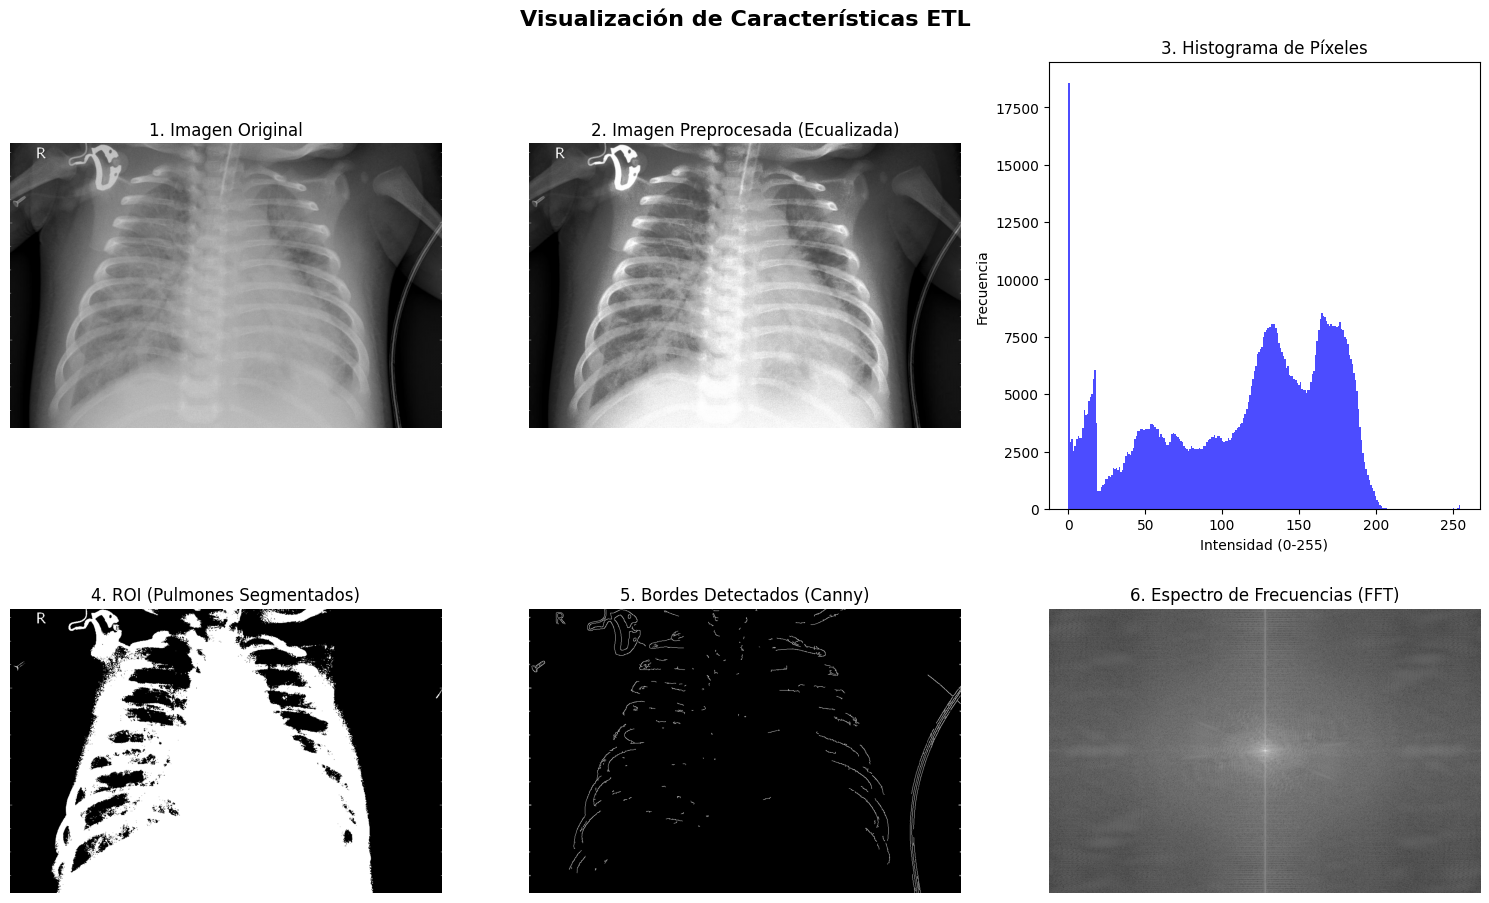

In [12]:
# BLOQUE 8: VISUALIZACIONES 

# 1. Buscamos automáticamente una imagen de muestra para visualizar (Ej. Neumonía)
ruta_muestra = glob.glob(os.path.join(ruta_base, "train", "PNEUMONIA", "*.jpeg"))[0]

# Leemos la imagen original en escala de grises
img_original = cv2.imread(ruta_muestra, cv2.IMREAD_GRAYSCALE)

# 2. Generamos las diferentes transformaciones (simulando lo que hace el ETL)

# a) Imagen Preprocesada (Aplicamos ecualización de histograma para mejorar el contraste)
img_preprocesada = cv2.equalizeHist(img_original)

# b) ROI (Umbralización de Otsu)
umbral, roi_otsu = cv2.threshold(img_preprocesada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# c) Bordes (Filtro Canny)
bordes_canny = cv2.Canny(img_preprocesada, 100, 200)

# d) FFT (Transformada de Fourier)
f = fft2(img_preprocesada)
fshift = fftshift(f)
# Para poder visualizar la FFT, necesitamos aplicar el logaritmo a la magnitud
magnitud_espectral_visual = np.log(np.abs(fshift) + 1)

# 3. Configuramos la figura o "lienzo" de Matplotlib (2 filas, 3 columnas)
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Visualización de Características ETL", fontsize=16, fontweight='bold')

# --- Gráfica 1: Original ---
ax[0, 0].imshow(img_original, cmap='gray')
ax[0, 0].set_title("1. Imagen Original")
ax[0, 0].axis('off')

# --- Gráfica 2: Preprocesada ---
ax[0, 1].imshow(img_preprocesada, cmap='gray')
ax[0, 1].set_title("2. Imagen Preprocesada (Ecualizada)")
ax[0, 1].axis('off')

# --- Gráfica 3: Histograma ---
ax[0, 2].hist(img_original.ravel(), bins=256, color='blue', alpha=0.7)
ax[0, 2].set_title("3. Histograma de Píxeles")
ax[0, 2].set_xlabel("Intensidad (0-255)")
ax[0, 2].set_ylabel("Frecuencia")

# --- Gráfica 4: ROI (Otsu) ---
ax[1, 0].imshow(roi_otsu, cmap='gray')
ax[1, 0].set_title("4. ROI (Pulmones Segmentados)")
ax[1, 0].axis('off')

# --- Gráfica 5: Bordes (Canny) ---
ax[1, 1].imshow(bordes_canny, cmap='gray')
ax[1, 1].set_title("5. Bordes Detectados (Canny)")
ax[1, 1].axis('off')

# --- Gráfica 6: FFT ---
ax[1, 2].imshow(magnitud_espectral_visual, cmap='gray')
ax[1, 2].set_title("6. Espectro de Frecuencias (FFT)")
ax[1, 2].axis('off')

# Ajustamos el espaciado y mostramos el gráfico
plt.tight_layout()
plt.show()